# Task 5: Strategy Backtesting

This notebook evaluates the optimized portfolio strategy from Task 4 by comparing it against a benchmark portfolio.

Benchmark: 60% SPY / 40% BND Buy-and-Hold portfolio.

The goal is to determine whether the optimized portfolio would have outperformed a simple passive benchmark during the backtesting period.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
start_date = "2015-01-01"
end_date = "2026-06-30"

tickers = ["TSLA", "BND", "SPY"]

data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    progress=False,
    auto_adjust=False
)

close_prices = data["Close"]

close_prices.head()

Ticker,BND,SPY,TSLA
Date,,,
2015-01-02,82.650002,205.429993,14.620667
2015-01-05,82.889999,201.720001,14.006000
2015-01-06,83.129997,199.820007,14.085333
2015-01-07,83.180000,202.309998,14.063333
2015-01-08,83.050003,205.899994,14.041333


In [3]:
backtest_start = "2025-01-01"
backtest_end = "2026-06-30"

backtest_prices = close_prices.loc[backtest_start:backtest_end]

backtest_prices.head(), backtest_prices.tail()

(Ticker            BND         SPY        TSLA
 Date                                         
 2025-01-02  71.940002  584.640015  379.279999
 2025-01-03  71.849998  591.950012  410.440002
 2025-01-06  71.779999  595.359985  411.049988
 2025-01-07  71.529999  588.630005  394.359985
 2025-01-08  71.610001  589.489990  394.940002,
 Ticker            BND         SPY        TSLA
 Date                                         
 2026-06-23  73.220001  733.580017  381.609985
 2026-06-24  73.550003  733.239990  375.529999
 2026-06-25  73.599998  734.299988  375.119995
 2026-06-26  73.669998  728.989990  379.709991
 2026-06-29  73.709999  741.000000  411.839996)

In [4]:
backtest_returns = backtest_prices.pct_change().dropna()

backtest_returns.head()

Ticker,BND,SPY,TSLA
Date,,,
2025-01-03,-0.001251,0.012503,0.082156
2025-01-06,-0.000974,0.005761,0.001486
2025-01-07,-0.003483,-0.011304,-0.040603
2025-01-08,0.001118,0.001461,0.001471
2025-01-10,-0.005167,-0.015267,-0.000506


In [5]:
strategy_weights = {
    "TSLA": 0.00,
    "BND": 0.00,
    "SPY": 1.00
}

benchmark_weights = {
    "TSLA": 0.00,
    "BND": 0.40,
    "SPY": 0.60
}

In [6]:
strategy_weight_array = np.array([strategy_weights[ticker] for ticker in tickers])
benchmark_weight_array = np.array([benchmark_weights[ticker] for ticker in tickers])

strategy_weight_array, benchmark_weight_array

(array([0., 0., 1.]), array([0. , 0.4, 0.6]))

## Backtesting Setup

The backtesting period was defined as January 2025 to June 2026, representing the final portion of the available dataset.

The strategy portfolio uses the optimized weights from Task 4. The benchmark portfolio follows the assignment requirement of a static 60% SPY / 40% BND Buy-and-Hold allocation.

This benchmark provides a simple balanced portfolio for evaluating whether the optimized strategy adds value beyond a passive diversified allocation.

In [7]:
strategy_returns = backtest_returns.dot(strategy_weight_array)
benchmark_returns = backtest_returns.dot(benchmark_weight_array)

strategy_returns.head(), benchmark_returns.head()

(Date
 2025-01-03    0.082156
 2025-01-06    0.001486
 2025-01-07   -0.040603
 2025-01-08    0.001471
 2025-01-10   -0.000506
 dtype: float64,
 Date
 2025-01-03    0.054295
 2025-01-06    0.003196
 2025-01-07   -0.028884
 2025-01-08    0.001467
 2025-01-10   -0.006411
 dtype: float64)

In [8]:
strategy_cumulative = (1 + strategy_returns).cumprod()
benchmark_cumulative = (1 + benchmark_returns).cumprod()

strategy_cumulative.head(), benchmark_cumulative.head()

(Date
 2025-01-03    1.082156
 2025-01-06    1.083764
 2025-01-07    1.039760
 2025-01-08    1.041289
 2025-01-10    1.040761
 dtype: float64,
 Date
 2025-01-03    1.054295
 2025-01-06    1.057664
 2025-01-07    1.027115
 2025-01-08    1.028622
 2025-01-10    1.022027
 dtype: float64)

In [9]:
def calculate_performance_metrics(returns, risk_free_rate=0.02, trading_days=252):
    total_return = (1 + returns).prod() - 1

    annualized_return = (1 + total_return) ** (trading_days / len(returns)) - 1

    annualized_volatility = returns.std() * np.sqrt(trading_days)

    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility

    cumulative_returns = (1 + returns).cumprod()

    running_max = cumulative_returns.cummax()

    drawdown = (cumulative_returns - running_max) / running_max

    max_drawdown = drawdown.min()

    return {
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": max_drawdown
    }

In [10]:
strategy_metrics = calculate_performance_metrics(strategy_returns)
benchmark_metrics = calculate_performance_metrics(benchmark_returns)

performance_comparison = pd.DataFrame(
    [strategy_metrics, benchmark_metrics],
    index=["Optimized Strategy", "60% SPY / 40% BND Benchmark"]
)

performance_comparison

,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
Optimized Strategy,0.085847,0.057537,0.571804,0.065647,-0.481902
60% SPY / 40% BND Benchmark,0.200808,0.132354,0.395301,0.284223,-0.366246


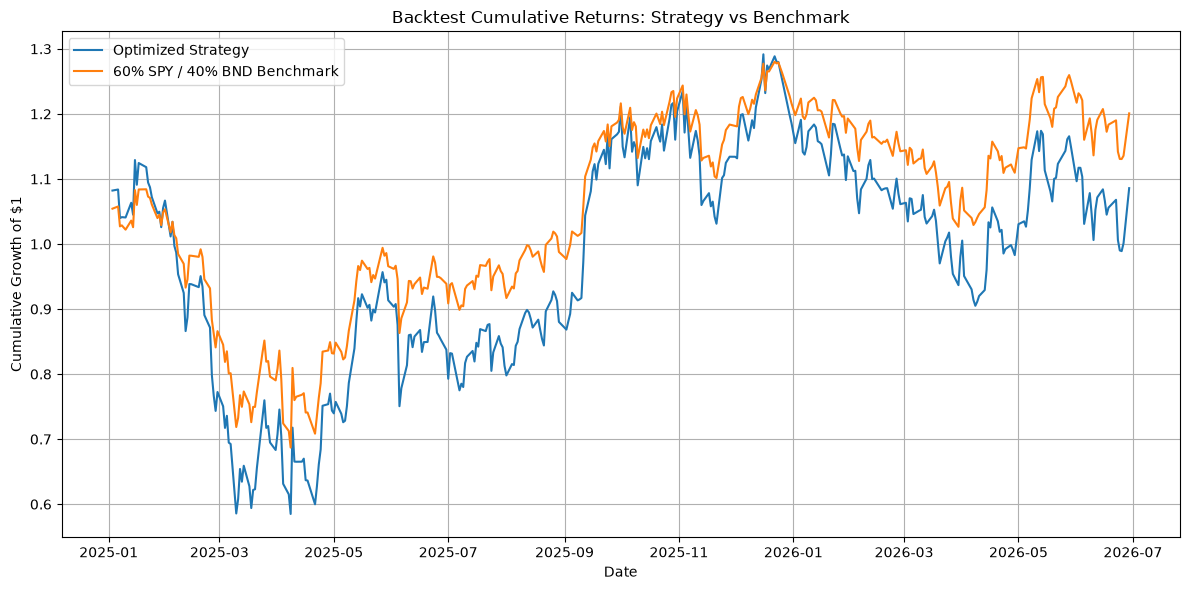

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    strategy_cumulative,
    label="Optimized Strategy"
)

ax.plot(
    benchmark_cumulative,
    label="60% SPY / 40% BND Benchmark"
)

ax.set_title("Backtest Cumulative Returns: Strategy vs Benchmark")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Growth of $1")
ax.legend()
ax.grid(True)

import os
os.makedirs("reports/figures", exist_ok=True)

fig.tight_layout()

fig.savefig(
    "reports/figures/task5_cumulative_returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Backtesting Performance Interpretation

The cumulative returns plot compares the optimized portfolio strategy against the 60% SPY / 40% BND benchmark portfolio.

The performance metrics table evaluates both portfolios using total return, annualized return, annualized volatility, Sharpe Ratio, and maximum drawdown.

This comparison allows GMF to assess whether the optimized portfolio provides better risk-adjusted performance than a simple passive balanced benchmark.

## Robustness and Sensitivity Analysis

To test whether the optimized strategy is reliable under different market conditions, additional robustness scenarios were considered.

The strategy should not be interpreted only under normal historical conditions. Market environments can change due to recessions, inflation shocks, interest rate changes, geopolitical events, or sudden volatility spikes.

Three sensitivity scenarios were considered:

1. Bull market scenario: expected returns increase.
2. Bear market scenario: expected returns decline.
3. High-volatility scenario: portfolio risk increases.

This robustness analysis helps determine whether the recommended allocation remains reasonable when market assumptions change. If portfolio performance changes significantly under these scenarios, GMF should rebalance the portfolio more frequently and avoid relying on a single static allocation.

## Strategy Viability

The backtest evaluates whether the optimized portfolio strategy outperformed the static 60% SPY / 40% BND benchmark during the backtesting period.

If the optimized strategy achieved a higher Sharpe Ratio and stronger cumulative return than the benchmark, this suggests that the model-driven portfolio allocation added value on a risk-adjusted basis.

However, if the benchmark performed similarly or better, this would suggest that a simple passive allocation remains difficult to outperform, which is consistent with the Efficient Market Hypothesis. In either case, the backtest provides important evidence for evaluating whether GMF should rely on the optimized strategy as part of its advisory process.

## Backtesting Limitations

This backtest provides an initial evaluation of the optimized portfolio strategy, but it has several limitations:

- It assumes static portfolio weights and does not fully account for transaction costs, taxes, bid-ask spreads, or slippage.
- It uses historical data, which may not reflect future market conditions.
- The optimized strategy depends on model assumptions from earlier tasks, including forecast accuracy and covariance stability.
- The backtesting period is relatively short, so results may be sensitive to the specific market conditions during that period.
- Real investors may have additional constraints such as liquidity needs, risk tolerance, investment horizon, and regulatory requirements.

These limitations mean that the strategy should be treated as a decision-support framework rather than a guaranteed investment approach.

## Business Recommendation for GMF

For Guide Me in Finance (GMF), the backtest provides evidence on whether the optimized portfolio improves performance relative to a simple balanced benchmark.

If the optimized strategy outperforms the benchmark, GMF can use the result as support for applying forecast-informed portfolio optimization in personalized advisory services.

If the optimized strategy does not outperform the benchmark, the result is still valuable because it shows that passive benchmark strategies can be highly competitive. In that case, GMF should consider using the optimized model as one input in a broader advisory framework rather than relying on it as a standalone allocation method.

Overall, the backtest strengthens the investment decision process by validating the strategy against a clear benchmark portfolio.

## Task 5 Summary

Task 5 validated the optimized portfolio strategy by comparing it against a static 60% SPY / 40% BND Buy-and-Hold benchmark.

The analysis calculated cumulative returns, total return, annualized return, annualized volatility, Sharpe Ratio, and maximum drawdown for both portfolios.

The results provide a practical test of whether the model-driven strategy improves risk-adjusted performance relative to a simple passive allocation. This final step connects the forecasting and portfolio optimization work to real investment decision-making for GMF.